# Notebook 3c — RF con CV por animal: Lesiones TB **con explotación como covariable**
### Tuberculosis bovina

Evalúa el Random Forest usando **validación cruzada estratificada por animal**
(RepeatedStratifiedKFold) **incluyendo la explotación (Expl) como covariable categórica**
junto a los biomarcadores.

> **Pregunta de investigación:** ¿añade la explotación (granja) capacidad predictiva
> a los biomarcadores individuales (vitamina D, calcio, serología parasitaria, edad, raza)
> para predecir el estado de TB bovina dentro de las granjas conocidas?
> La explotación es fija como covariable; la selección hacia atrás opera solo sobre los
> biomarcadores para identificar cuáles aportan valor incremental.

**Comparar con:**
- *Notebook 2* (LOFO): generalización real a granjas nuevas.
- *Notebook 2c* (CV animal, sin expl): señal de biomarcadores sin info de granja.
- *Este notebook (3c)*: señal de biomarcadores **condicionada a la granja conocida**.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     LeaveOneGroupOut)
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, matthews_corrcoef, recall_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Lesiones_TB")
d = tb.drop_sparse_rows(d)

# Features: biomarcadores + Expl (covariable categórica de granja)
EXPL_COL = tb.GROUP_COL   # "Expl"
FEATURES_BIO = tb.MODEL_FEATURES          # biomarcadores (sin Expl)
FEATURES_ALL = tb.MODEL_FEATURES + [EXPL_COL]  # modelo completo con granja

# Definir qué es numérico/categórico dentro del conjunto ampliado
NUM_3C  = tb.NUM_FEATURES
CAT_3C  = tb.CAT_FEATURES + [EXPL_COL]   # RAZA2 + Expl

X_all = d[FEATURES_ALL].copy()
y     = d["Lesiones_TB"].astype(int).values
g     = d[EXPL_COL].values   # guardado para referencia; NO usado para estratificar CV

print(f"Dataset: n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Features biomarcadores ({len(FEATURES_BIO)}): {FEATURES_BIO}")
print(f"Covariable adicional: {EXPL_COL} — niveles: {sorted(d[EXPL_COL].unique())}")
print(f"\nNota: Expl se usa como covariable del modelo (OHE) pero NO para estructurar el CV.")
print(f"Línea base PR-AUC (prevalencia) = {y.mean():.3f}")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103, prevalencia=0.612
Features biomarcadores (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Covariable adicional: Expl — niveles: ['VA32D', 'VC30D', 'VC94C', 'WZ72B']

Nota: Expl se usa como covariable del modelo (OHE) pero NO para estructurar el CV.
Línea base PR-AUC (prevalencia) = 0.612


## 2. Random Forest y estrategia de validación cruzada

**CV por animal con explotación como feature (RepeatedStratifiedKFold, 5×10):**
- Estratificado por `y` (balance de clases).
- `Expl` entra en el modelo como feature categórica (OHE) — **covariable fija**.
- La selección hacia atrás opera solo sobre los biomarcadores; `Expl` siempre está presente.
- Permite responder: "dado que conocemos la granja, ¿qué biomarcadores aportan valor adicional?"

In [2]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_3c(feature_list, n_estimators=100):
    """Pipeline con Expl como covariable categórica fija."""
    num_f = [f for f in feature_list if f in NUM_3C]
    cat_f = [f for f in feature_list if f in CAT_3C]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_3c(bio_features, X, y, cv=None, detailed=False, n_estimators=100):
    """PR-AUC y métricas con CV por animal. Expl siempre incluida como covariable."""
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    # Modelo siempre usa: biomarcadores seleccionados + Expl
    feats = list(bio_features) + ([EXPL_COL] if EXPL_COL not in bio_features else [])
    Xs = X[feats]
    pipe_tmpl = make_pipe_3c(feats, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        rows.append(dict(
            prauc = average_precision_score(y[te], p),
            roc   = roc_auc_score(y[te], p),
            brier = brier_score_loss(y[te], p),
            mcc   = matthews_corrcoef(y[te], pred),
            sens  = recall_score(y[te], pred, pos_label=1, zero_division=0),
            spec  = recall_score(y[te], pred, pos_label=0, zero_division=0),
        ))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.prauc.mean(), df_r.prauc.std()

# Evaluación baseline con todos los biomarcadores + Expl
print("Evaluación baseline RF (todos los biomarcadores + Expl, CV por animal):")
base_m, base_s = cv_metrics_3c(FEATURES_BIO, X_all, y)
print(f"  PR-AUC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Línea base (prevalencia) = {y.mean():.3f}")

Evaluación baseline RF (todos los biomarcadores + Expl, CV por animal):
  PR-AUC = 0.793 ± 0.070
  Línea base (prevalencia) = 0.612


## 3. Pipeline de selección de características

**Expl es una covariable fija** — siempre presente en el modelo.
La selección hacia atrás opera exclusivamente sobre los **biomarcadores**:
1. Importancia de permutación sobre modelo completo (todos los biomarcadores + Expl) → ranking de biomarcadores.
2. Eliminación hacia atrás de biomarcadores; en cada paso `Expl` permanece en el modelo.
3. Selección: subconjunto de biomarcadores más pequeño con PR-AUC ≥ máx − 1·DE.

Paso 1: Ajustando RF completo (biomarcadores + Expl) para ranking de importancia...
OOB Score (en muestra): 0.641

Ranking importancia de permutación (biomarcadores + Expl):
                 pretty  imp_mean  imp_std
                   Expl    0.1464   0.0361
             Vitamina D    0.0584   0.0114
                 Calcio    0.0537   0.0115
     Anaplasma spp. (+)    0.0164   0.0045
log(1+Carga piroplasma)    0.0161   0.0038
            Edad (años)    0.0143   0.0055
     Theileria spp. (+)    0.0042   0.0020
                   Raza    0.0026   0.0010
         Piroplasma (+)    0.0009   0.0004


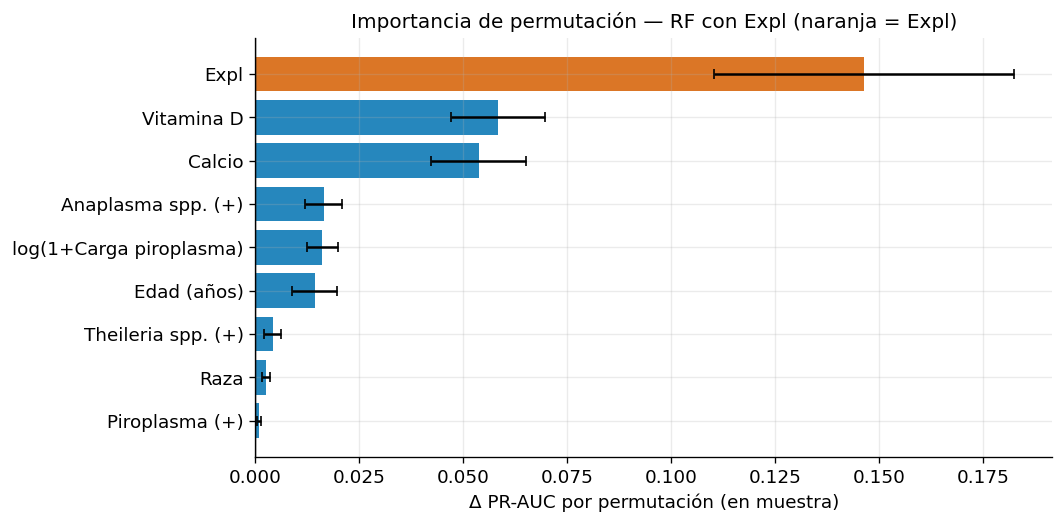

In [3]:
print("Paso 1: Ajustando RF completo (biomarcadores + Expl) para ranking de importancia...")
full_pipe = make_pipe_3c(FEATURES_ALL).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

# Importancia de permutación solo sobre los biomarcadores (Expl fija)
pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="average_precision",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
# Los índices de features coinciden con FEATURES_ALL
imp_df = pd.DataFrame({
    "feature":  FEATURES_ALL,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (biomarcadores + Expl):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
order = imp_df.sort_values("imp_mean")
colors_bar = [PALETTE[1] if f == EXPL_COL else PALETTE[0] for f in order.feature]
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=colors_bar, capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF con Expl (naranja = Expl)")
plt.tight_layout(); plt.savefig("figures/fig_03c_perm_importance_full.png"); plt.show()

In [4]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)

# Orden de eliminación solo para biomarcadores (Expl no se elimina)
bio_imp = imp_df[imp_df.feature != EXPL_COL].sort_values("imp_mean", ascending=True)
elim_order = bio_imp["feature"].tolist()
print(f"Orden de eliminación de biomarcadores: {elim_order}")
print(f"Covariable fija: {EXPL_COL}\n")
print("Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...\n")

current_bio = FEATURES_BIO.copy()
history = []

m0, s0 = cv_metrics_3c(current_bio, X_all, y, cv=CV_SEL)
history.append({"n": len(current_bio), "bio_features": current_bio.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_bio):2d} bio + Expl [baseline] PR-AUC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_bio or len(current_bio) <= 1:
        break
    test_bio = [f for f in current_bio if f != feat]
    m, s = cv_metrics_3c(test_bio, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_bio), "bio_features": test_bio.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_bio):2d} bio + Expl [-{feat:20s}] PR-AUC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_bio = test_bio

hist_df = pd.DataFrame(history)

Orden de eliminación de biomarcadores: ['PIROPLASMA', 'RAZA2', 'THEILERIA', 'EDAD', 'PIROPLASMA_Q_log', 'ANAPLASMA', 'CALCIO', 'VITAMINA_D']
Covariable fija: Expl

Paso 2: Eliminación hacia atrás de biomarcadores (Expl siempre presente)...

   8 bio + Expl [baseline] PR-AUC=0.804±0.078
   7 bio + Expl [-PIROPLASMA          ] PR-AUC=0.817±0.078  Δ=+0.013
   6 bio + Expl [-RAZA2               ] PR-AUC=0.816±0.074  Δ=+0.012
   5 bio + Expl [-THEILERIA           ] PR-AUC=0.807±0.073  Δ=+0.003
   4 bio + Expl [-EDAD                ] PR-AUC=0.824±0.085  Δ=+0.020
   3 bio + Expl [-PIROPLASMA_Q_log    ] PR-AUC=0.849±0.072  Δ=+0.045
   2 bio + Expl [-ANAPLASMA           ] PR-AUC=0.848±0.050  Δ=+0.044
   1 bio + Expl [-CALCIO              ] PR-AUC=0.794±0.060  Δ=-0.010


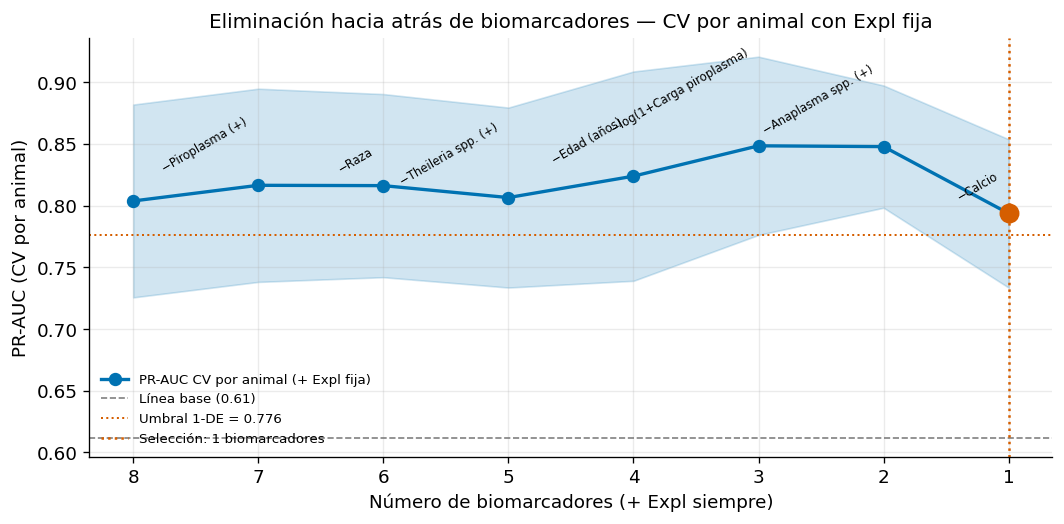


Biomarcadores SELECCIONADOS (1): ['VITAMINA_D']
Modelo final: ['VITAMINA_D'] + [Expl] (fija)


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7,
        label="PR-AUC CV por animal (+ Expl fija)")
ax.fill_between(hist_df.n,
                hist_df["mean"] - hist_df["std"],
                hist_df["mean"] + hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Línea base ({y.mean():.2f})")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} biomarcadores")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de biomarcadores (+ Expl siempre)"); ax.set_ylabel("PR-AUC (CV por animal)")
ax.set_title("Eliminación hacia atrás de biomarcadores — CV por animal con Expl fija")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_03c_feature_selection_curve.png"); plt.show()

SELECTED_BIO_3C = list(parsimonious.bio_features)
print(f"\nBiomarcadores SELECCIONADOS ({len(SELECTED_BIO_3C)}): {SELECTED_BIO_3C}")
print(f"Modelo final: {SELECTED_BIO_3C} + [{EXPL_COL}] (fija)")

Calculando accuracy para cada subconjunto (≈1 min)...
   8 bio [-—(baseline)         ] Acc=0.637±0.094
   7 bio [-PIROPLASMA          ] Acc=0.630±0.089
   6 bio [-RAZA2               ] Acc=0.618±0.102
   5 bio [-THEILERIA           ] Acc=0.627±0.072
   4 bio [-EDAD                ] Acc=0.640±0.096
   3 bio [-PIROPLASMA_Q_log    ] Acc=0.709±0.092
   2 bio [-ANAPLASMA           ] Acc=0.659±0.091
   1 bio [-CALCIO              ] Acc=0.640±0.072


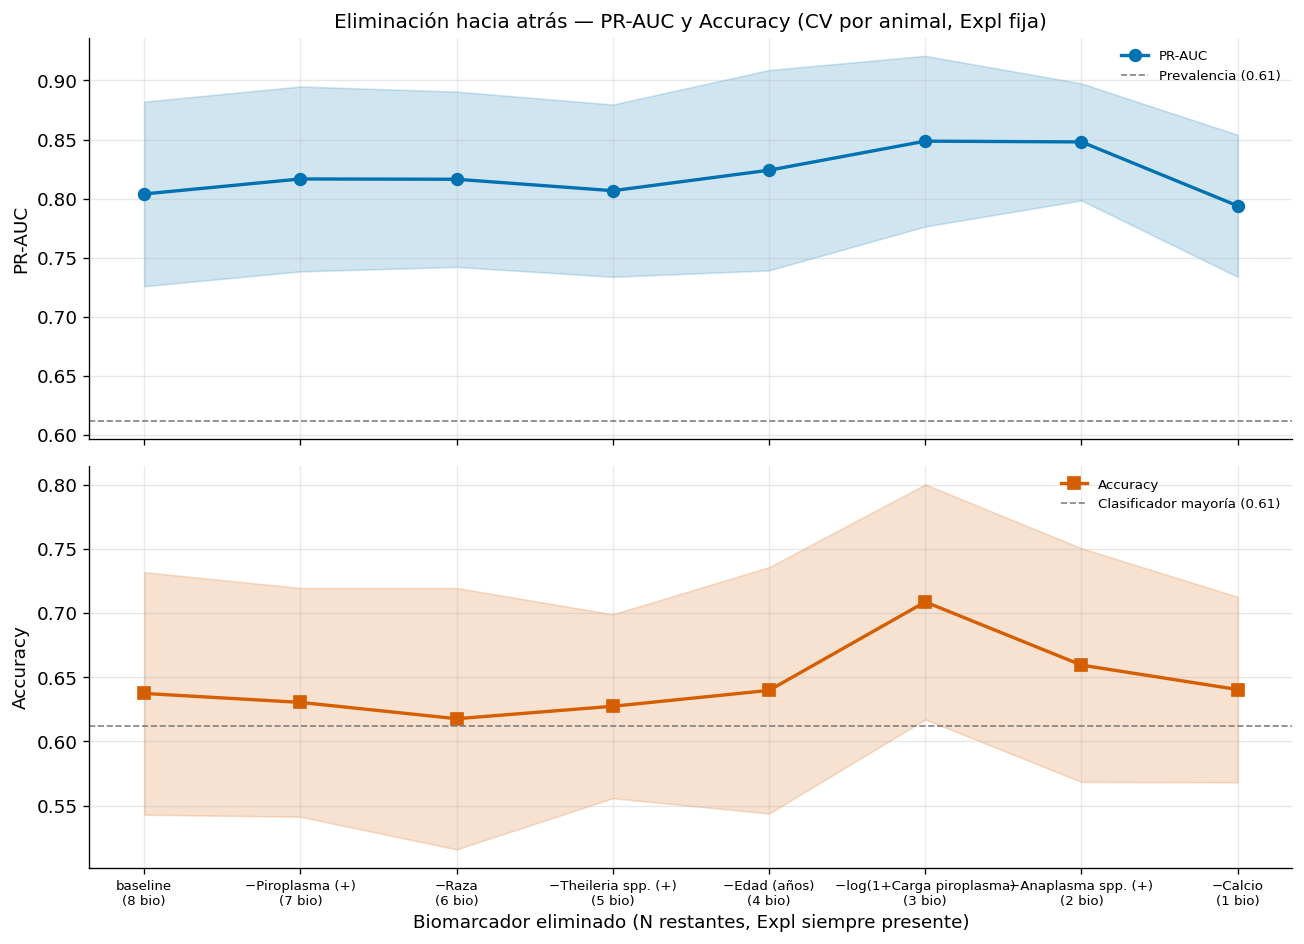

In [6]:
from sklearn.metrics import accuracy_score

def _cv_accuracy_3c(bio_features, X, y, cv):
    feats = list(bio_features) + [EXPL_COL]
    Xs = X[feats]
    pipe_tmpl = make_pipe_3c(feats)
    accs = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        accs.append(accuracy_score(y[te], pf.predict(Xs.iloc[te])))
    return np.mean(accs), np.std(accs)

print("Calculando accuracy para cada subconjunto (≈1 min)...")
acc_means, acc_stds = [], []
for _, row in hist_df.iterrows():
    m, s = _cv_accuracy_3c(row["bio_features"], X_all, y, CV_SEL)
    acc_means.append(m); acc_stds.append(s)
    print(f"  {int(row.n):2d} bio [-{row['removed']:20s}] Acc={m:.3f}±{s:.3f}")

hist_df = hist_df.assign(acc_mean=acc_means, acc_std=acc_stds)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
x = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} bio)"
    else:
        pretty = tb.PRETTY.get(row["removed"], row["removed"])
        lbl = f"−{pretty}\n({int(row.n)} bio)"
    labels.append(lbl)

ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="PR-AUC")
ax1.fill_between(x, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"],
                 alpha=0.18, color=PALETTE[0])
ax1.axhline(y.mean(), ls="--", color="grey", lw=1, label=f"Prevalencia ({y.mean():.2f})")
ax1.set_ylabel("PR-AUC"); ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("Eliminación hacia atrás — PR-AUC y Accuracy (CV por animal, Expl fija)")

ax2 = axes[1]
majority_cls = max(y.mean(), 1 - y.mean())
ax2.plot(x, hist_df["acc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="Accuracy")
ax2.fill_between(x, hist_df["acc_mean"]-hist_df["acc_std"], hist_df["acc_mean"]+hist_df["acc_std"],
                 alpha=0.18, color=PALETTE[1])
ax2.axhline(majority_cls, ls="--", color="grey", lw=1,
            label=f"Clasificador mayoría ({majority_cls:.2f})")
ax2.set_ylabel("Accuracy"); ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Biomarcador eliminado (N restantes, Expl siempre presente)")
plt.tight_layout()
plt.savefig("figures/fig_03c_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

In [ ]:
# Ajustar manualmente si se desea un subconjunto específico
SELECTED_BIO_3C = ["VITAMINA_D", "CALCIO",'ANAPLASMA']

FEATS_FINAL_3C = SELECTED_BIO_3C + [EXPL_COL]
Xs = X_all[FEATS_FINAL_3C].copy()
print(f"Modelo final — features ({len(FEATS_FINAL_3C)}): {FEATS_FINAL_3C}")
print(f"  Biomarcadores: {SELECTED_BIO_3C}")
print(f"  Covariable granja: [{EXPL_COL}]\n")

detailed_df = cv_metrics_3c(SELECTED_BIO_3C, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, con Expl):")
print(f"  PR-AUC = {m.prauc:.3f} ± {s.prauc:.3f}   (línea base = {y.mean():.3f})")
print(f"  ROC    = {m.roc:.3f}   ± {s.roc:.3f}")
print(f"  Brier  = {m.brier:.3f}  ± {s.brier:.3f}")
print(f"  MCC    = {m.mcc:.3f}   ± {s.mcc:.3f}")
print(f"  Sens   = {m.sens:.2f}   ± {s.sens:.2f}")
print(f"  Spec   = {m.spec:.2f}   ± {s.spec:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes, ["prauc", "roc", "mcc"], ["PR-AUC", "ROC-AUC", "MCC"]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    if col == "prauc":
        ax.axvline(y.mean(), color="grey", ls="--", lw=1.5, label=f"Base={y.mean():.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal (con Expl)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_03c_metrics_dist.png", bbox_inches="tight"); plt.show()

Modelo final — features (4): ['VITAMINA_D', 'CALCIO', 'ANAPLASMA', 'Expl']
  Biomarcadores: ['VITAMINA_D', 'CALCIO', 'ANAPLASMA']
  Covariable granja: [Expl]



## 5. Interpretabilidad global — SHAP

El modelo incluye `Expl` como feature categórica (OHE). Los valores SHAP de las
columnas `Expl_*` reflejan el efecto granja residual controlado en el modelo.
Los valores SHAP de los biomarcadores representan su contribución **condicionada a la granja**.

In [ ]:
FINAL_3C = make_pipe_3c(FEATS_FINAL_3C, n_estimators=500).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_3C.named_steps['clf'].oob_score_:.3f}")

prep_3c  = FINAL_3C.named_steps["prep"]
clf_3c   = FINAL_3C.named_steps["clf"]
Xt_3c    = prep_3c.transform(Xs)
names_3c = list(prep_3c.get_feature_names_out())

explainer_3c = shap.TreeExplainer(clf_3c)
shap_vals_3c = explainer_3c.shap_values(Xt_3c)

if isinstance(shap_vals_3c, list):
    sv_3c = shap_vals_3c[1]
elif np.asarray(shap_vals_3c).ndim == 3:
    sv_3c = np.asarray(shap_vals_3c)[:, :, 1]
else:
    sv_3c = np.asarray(shap_vals_3c)

exp_val_3c = (float(explainer_3c.expected_value[1])
              if isinstance(explainer_3c.expected_value, (list, np.ndarray))
              else float(explainer_3c.expected_value))

print(f"Features tras preprocesamiento : {names_3c}")
print(f"SHAP values shape              : {sv_3c.shape}")
print(f"Expected value (clase +)       : {exp_val_3c:.4f}")

OOB Score (en muestra): 0.680
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'ANAPLASMA', 'Expl_VA32D', 'Expl_VC30D', 'Expl_VC94C', 'Expl_WZ72B']
SHAP values shape              : (103, 7)
Expected value (clase +)       : 0.5045


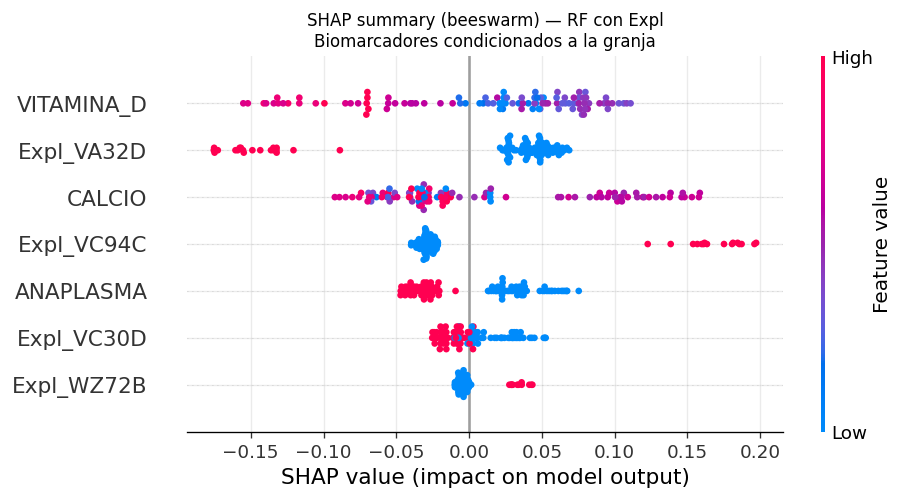

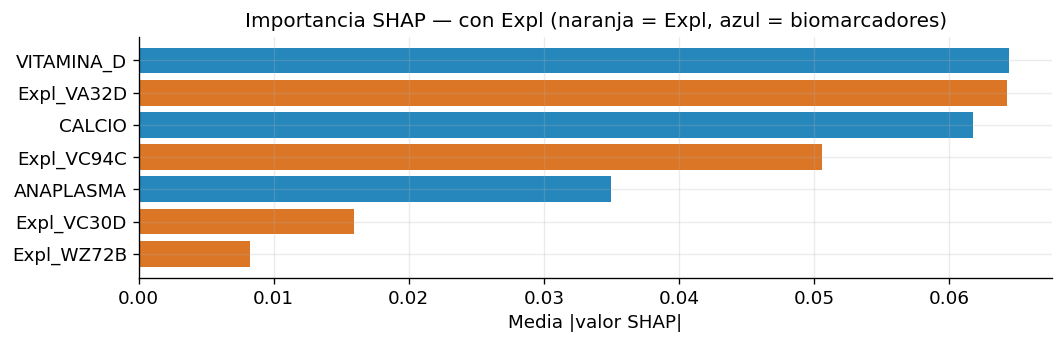

In [ ]:
plt.figure(figsize=(9, max(4, 0.5 * len(names_3c))))
shap.summary_plot(sv_3c, Xt_3c, feature_names=names_3c, show=False, max_display=len(names_3c))
plt.title("SHAP summary (beeswarm) — RF con Expl\n"
          "Biomarcadores condicionados a la granja", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_03c_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_3c = np.abs(sv_3c).mean(0)
si_3c = pd.DataFrame({"feature": names_3c, "mean_abs": mean_abs_3c}).sort_values("mean_abs")
# Colorear barras: naranja para columnas de Expl, azul para biomarcadores
colors_shap = [PALETTE[1] if "Expl" in f else PALETTE[0] for f in si_3c.feature]
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(names_3c))))
ax.barh(si_3c.feature, si_3c.mean_abs, color=colors_shap, alpha=0.85)
ax.set_xlabel("Media |valor SHAP|")
ax.set_title("Importancia SHAP — con Expl (naranja = Expl, azul = biomarcadores)")
plt.tight_layout(); plt.savefig("figures/fig_03c_shap_importance.png"); plt.show()

In [ ]:
shap.initjs()
order = np.argsort(FINAL_3C.predict_proba(Xs)[:, 1])
fp = shap.force_plot(
    exp_val_3c,
    sv_3c[order, :],
    Xt_3c[order, :] if hasattr(Xt_3c, '__getitem__') else Xt_3c[order],
    feature_names=names_3c,
)
shap.save_html("figures/fig_03c_shap_force_plot_global.html", fp)
display(fp)

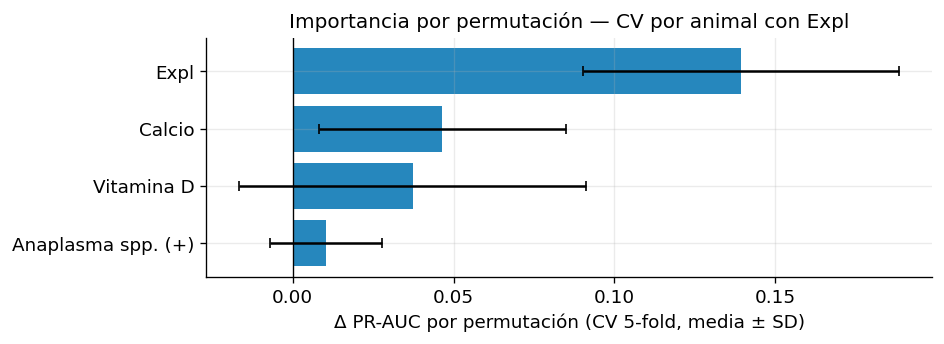

Estabilidad Spearman entre folds: 0.480


In [ ]:
from scipy.stats import spearmanr
imp_runs_3c = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_3c(FEATS_FINAL_3C)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="average_precision", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_3c.append(pd.Series(pi_f.importances_mean, index=FEATS_FINAL_3C))

imp_mat_3c = pd.concat(imp_runs_3c, axis=1)
imp_ord_3c = imp_mat_3c.mean(axis=1).sort_values().index

R = imp_mat_3c.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(FEATS_FINAL_3C))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_3c],
        imp_mat_3c.mean(axis=1)[imp_ord_3c],
        xerr=imp_mat_3c.std(axis=1)[imp_ord_3c],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal con Expl")
plt.tight_layout(); plt.savefig("figures/fig_03c_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO']


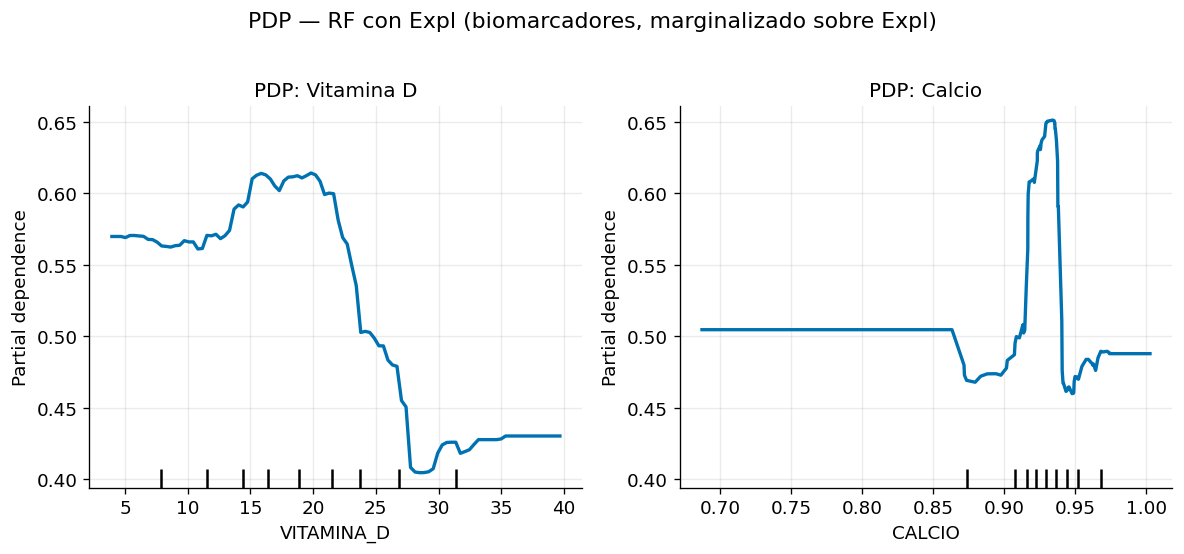

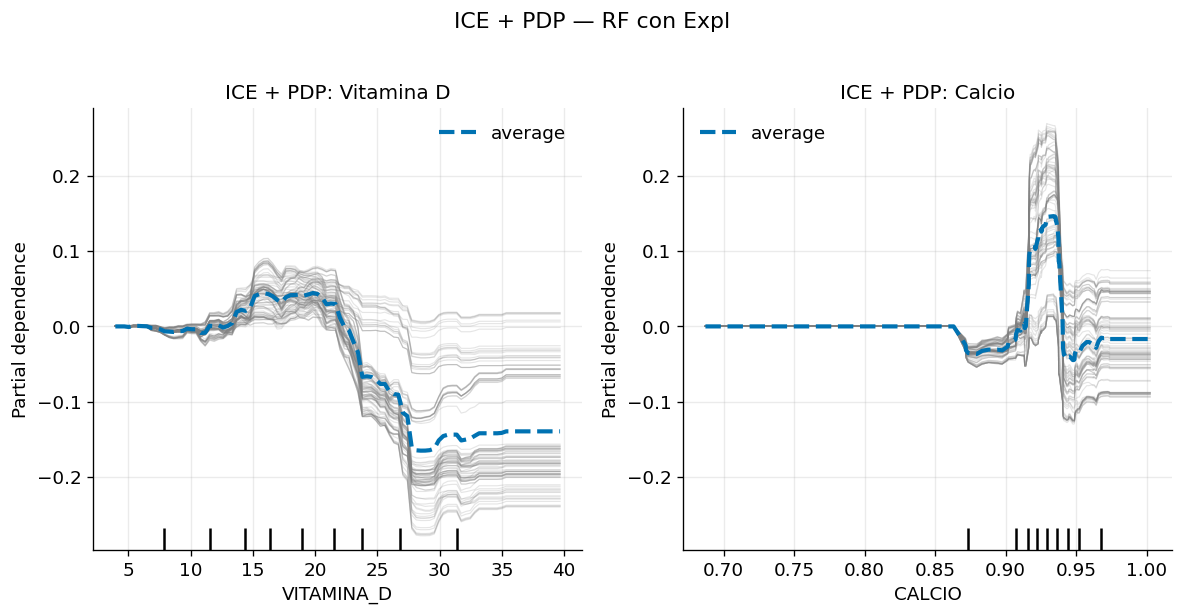

In [ ]:
CONT_3C = [f for f in FEATS_FINAL_3C if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_3C:
    CONT_3C = [f for f in FEATS_FINAL_3C if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_3C}")
if CONT_3C:
    n_c = len(CONT_3C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3C, Xs, CONT_3C, kind="average",
        ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_3C):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF con Expl (biomarcadores, marginalizado sobre Expl)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03c_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_3C, Xs, CONT_3C, kind="both",
        ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_3C):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF con Expl", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03c_ice.png", bbox_inches="tight"); plt.show()

## 7. Accumulated Local Effects (ALE)

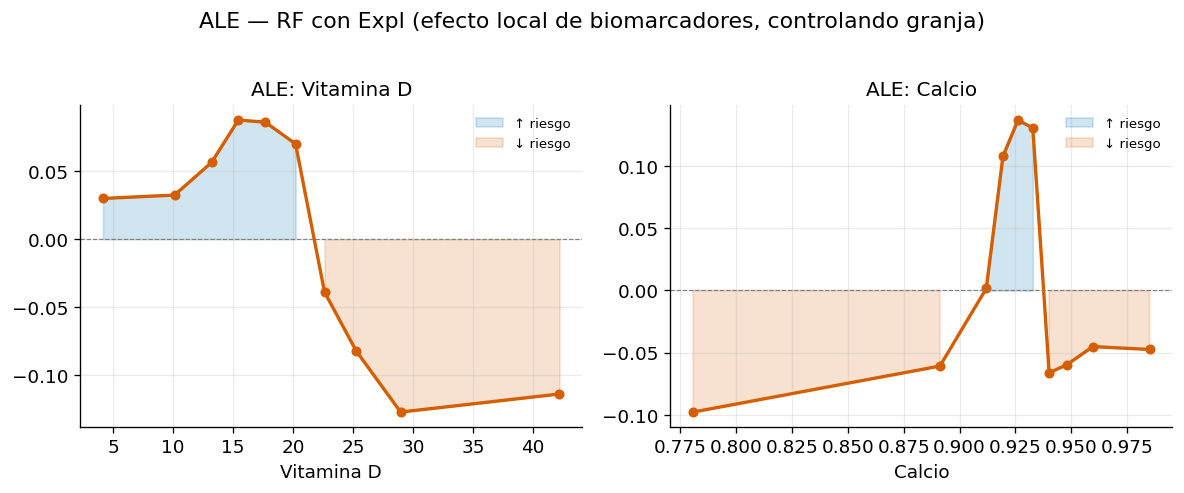

In [ ]:
def ale_1d(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, 1] - model.predict_proba(lo)[:, 1]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_3C:
    n_c = len(CONT_3C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3C):
        cx, ale = ale_1d(FINAL_3C, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF con Expl (efecto local de biomarcadores, controlando granja)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03c_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

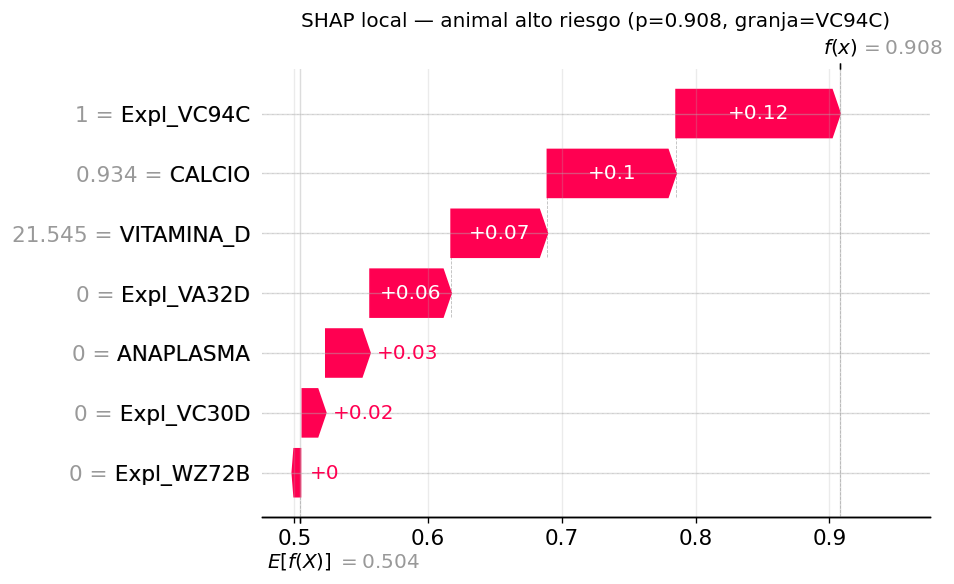

Animal 64: p=0.908, clase real=1, granja=VC94C


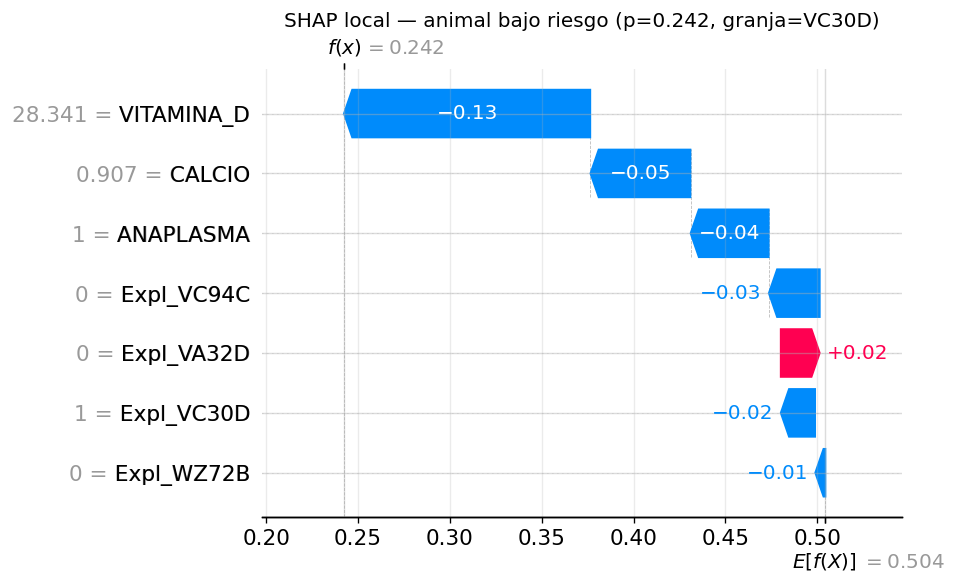

Animal 25: p=0.242, clase real=0, granja=VC30D


In [ ]:
p_all_3c = FINAL_3C.predict_proba(Xs)[:, 1]
idx_pos  = int(np.argmax(p_all_3c))
idx_neg  = int(np.argmin(p_all_3c))

shap_exp_3c = shap.Explanation(values=sv_3c, base_values=exp_val_3c,
                                data=Xt_3c, feature_names=names_3c)

for tag, idx in [("alto_riesgo", idx_pos), ("bajo_riesgo", idx_neg)]:
    farm_ref = g[idx]
    fig, _ = plt.subplots(figsize=(10, 4))
    shap.plots.waterfall(shap_exp_3c[idx], max_display=len(names_3c), show=False)
    plt.title(f"SHAP local — animal {tag.replace('_',' ')} (p={p_all_3c[idx]:.3f}, granja={farm_ref})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_03c_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p={p_all_3c[idx]:.3f}, clase real={y[idx]}, granja={farm_ref}")

## 9. Contrafactuales (sobre biomarcadores, granja fija)

In [ ]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print("CONTRAFACTUALES — biomarcadores (granja fija en valor real)")
print("=" * 60)
for tag, row, target_cls in [("ALTO riesgo", high_row, 0), ("BAJO riesgo", low_row, 1)]:
    pred = int(FINAL_3C.predict(pd.DataFrame([row]))[0])
    p    = FINAL_3C.predict_proba(pd.DataFrame([row]))[0, 1]
    print(f"\nAnimal {tag} (predicha={pred}, p={p:.3f}, granja={row[EXPL_COL]}), objetivo → clase {target_cls}")
    for feat in CONT_3C:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_3C, row.to_dict(), feat, lo_v, hi_v, target_cls)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

CONTRAFACTUALES — biomarcadores (granja fija en valor real)

Animal ALTO riesgo (predicha=1, p=0.908, granja=VC94C), objetivo → clase 0
  Vitamina D                    : actual=21.55 → no alcanzable
  Calcio                        : actual=0.93 → no alcanzable

Animal BAJO riesgo (predicha=0, p=0.242, granja=VC30D), objetivo → clase 1
  Vitamina D                    : actual=28.34 → no alcanzable
  Calcio                        : actual=0.91 → no alcanzable


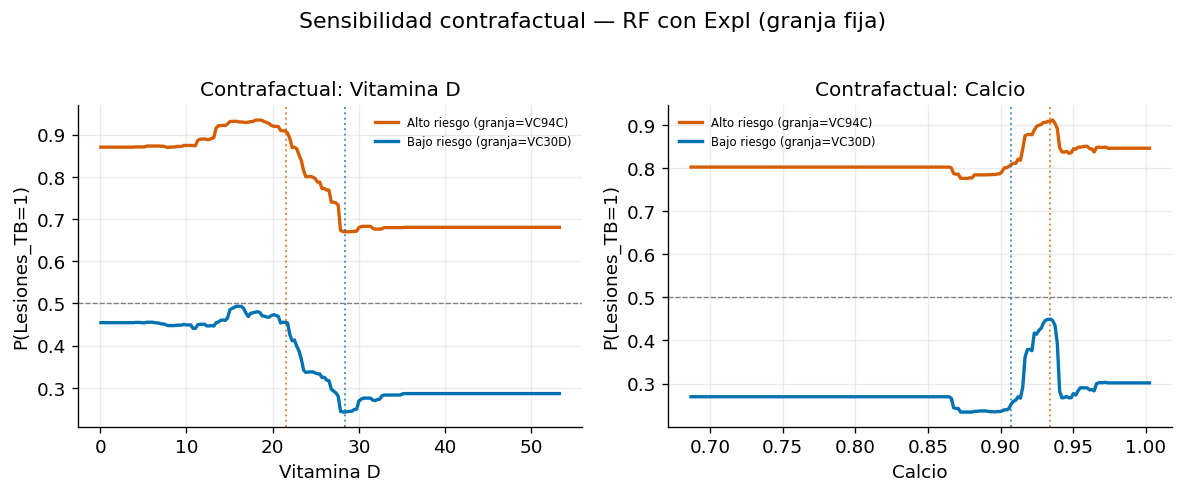

In [ ]:
if CONT_3C:
    n_c = len(CONT_3C)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_3C):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo", high_row, PALETTE[1]), ("Bajo riesgo", low_row, PALETTE[0])]:
            probs = [FINAL_3C.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, 1] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=f"{tag} (granja={row[EXPL_COL]})")
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(0.5, color="grey", ls="--", lw=0.8)
        ax.set_xlabel(tb.PRETTY.get(feat, feat)); ax.set_ylabel("P(Lesiones_TB=1)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=7)
    plt.suptitle("Sensibilidad contrafactual — RF con Expl (granja fija)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_03c_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa

| Métrica | Nb 2 — LOFO | Nb 2c — CV sin expl | **Nb 3c — CV + Expl fija** |
|---|---|---|---|
| PR-AUC | — | — | **—** |
| ROC-AUC | — | — | **—** |
| MCC | — | — | **—** |
| CV strategy | Leave-One-Farm-Out | RepeatedSKFold puro | **RepeatedSKFold + Expl feature** |
| Expl como feature | No | No | **Sí (OHE, siempre fija)** |
| Expl en CV split | Sí (LOFO) | No | **No** |

### Guía de interpretación

- **Si PR-AUC(3c) >> PR-AUC(2c):** la granja aporta señal predictiva adicional por encima de
  los biomarcadores solos; el animal DENTRO de su granja se predice mejor.

- **Si PR-AUC(3c) ≈ PR-AUC(2c):** la explotación no añade valor incremental; los
  biomarcadores capturan toda la señal disponible.

- **Si PR-AUC(3c) >> PR-AUC(2) (LOFO):** la mejora con Expl no generaliza a granjas nuevas
  → la granja actúa como confounder que el modelo memoriza, no como variable generalizable.

- **SHAP de Expl_*:** si las columnas de granja tienen SHAP elevado, la identidad de la
  granja es más predictiva que los biomarcadores → efecto de diseño (granja confunde TB).

### Implicaciones clínicas
Los contrafactuales en este notebook muestran los cambios de biomarcadores necesarios
para cambiar la predicción **dentro de la misma granja**. Son más accionables que los
contrafactuales LOFO pero menos generalizables a granjas nuevas.